In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter, filtfilt
from skimage.filters import threshold_otsu
import argparse
import numpy as np
from pathlib import Path
import json

In [36]:
def load_data(csv_path):
    """
    Load data from a CSV file.
    """
    df = pd.read_csv(csv_path)
    return df

def median_filter_data(data, kernel_size=11):
    """
    Apply median filtering to remove outliers.
    """
    return medfilt(data, kernel_size=kernel_size)   

def butter_lowpass(cutoff, fs, order=5):
    """ 
    Create a low-pass Butterworth filter.
    cutoff: Cutoff frequency in Hz
    fs: Sampling frequency in Hz
    order: Order of the filter
    """
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    """
    Apply a low-pass Butterworth filter to the data.
    """
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def average_data(df,window_size=30):
    """
    Smooth the data using a rolling average.
    """
    return df.rolling(window=window_size, center=True).mean()

def get_threshold(data):
    """
    Compute Otsu's threshold for the data.
    """
    return threshold_otsu(data) 

def compute_means_variances(df, threshold, sampling_interval, inference_per_cycle):
    """
    Compute means and variances above and below a threshold.
    """
    # # Above threshold
    # above_threshold = df[df > threshold]
    # average_power_active = above_threshold.mean()
    # variance_active = above_threshold.var()
    
    # # Below threshold
    # below_threshold = df[df < threshold]
    # average_power_idle = below_threshold.mean()
    # variance_idle = below_threshold.var()

    # sampling_interval = 0.1

    # These flags indicate whether the first and last samples are active, 
    # which affects how we identify active regions and their corresponding idle periods.
    is_active_first = False
    is_active_last = False

    #Identify active regions
    df_clean = df["smoothed"].dropna()
    is_active = df_clean > threshold

    #Identify transiton (start and end of each regions)
    change_points = np.diff(is_active.astype(int))

    # Identify start and end indices of active periods 
    # (transitions from inactive to active and vice versa)
    # and store them in two list
    start_indices = np.where(change_points == 1)[0] + 1
    end_indices = np.where(change_points == -1)[0] + 1

    # If the first sample is active
    if is_active.iloc[0]:
        start_indices = np.insert(start_indices, 0, 0)
        is_active_first = True

    # If the last sample is active
    if is_active.iloc[-1]:
        end_indices = np.append(end_indices, len(df.values))
        is_active_last = True
    
    # filter out fan active regions
    durations = [(end - start) * sampling_interval for start, end in zip(start_indices, end_indices)]
    # Set a max expected duration threshold (e.g., 2× typical inference duration)
    expected_duration = np.median(durations)
    #max_duration = expected_duration * 1.5

    regions =[]
    # A region is defined as a contiguous segment of active samples. 
    # We will compute the average power and variance for each active region, as well as the corresponding idle periods before and after it.
    # Intra means inside a region (active or idle indifferently)
    # Extra means taking into account all the regions

    for i,(start, end) in enumerate(zip(start_indices, end_indices)):
        
        ##################################
        # ACTIVE COMPUTATION
        ##################################

        duration = (end - start) * sampling_interval
        # if duration > max_duration:
        #     print(f"Skipping region {i} from {start} to {end} due to excessive duration: {duration:.2f}s")
        #     continue

        intra_activ_avg = df_clean.iloc[start:end].mean()
        intra_activ_var = df_clean.iloc[start:end].var()
        #energy_active = average_power_active * duration

    
        ##################################
        # IDLE COMPUTATION
        ##################################
        # Get idle region before
        if i == 0 and is_active_first:
            idle_before = None
        else:
            if i == 0:
                prev_end = 0
            else:
                prev_end = end_indices[i-1]
            
            idle_before = df_clean[prev_end:start]

        # Get idle region after
        if i == len(start_indices) - 1 and is_active_last:
            idle_after = None  # no next region
        else:
            if i == len(start_indices) - 1:
                next_start = len(df) - 1
            else: 
                next_start = start_indices[i + 1]
            idle_after = df_clean[end:next_start]

        # Combine available idle segments
        idle_segments = []
        if idle_before is not None and not idle_before.empty:
            idle_segments.append(idle_before)
        if idle_after is not None and not idle_after.empty:
            idle_segments.append(idle_after)

        # Calculate idle power and energy if there are idle segmentss
        if idle_segments:
            idle_combined = pd.concat(idle_segments)
            #idle_duration = len(idle_combined) * sampling_interval
            
            intra_idle_avg = idle_combined.mean()
            intra_idle_var = idle_combined.var()

            #idle_energy = idle_power * idle_duration

        intra_power_avg= (intra_activ_avg - intra_idle_avg)
        intra_power_var = (intra_activ_var + intra_idle_var)

        intra_energy_avg = intra_power_avg * duration / inference_per_cycle #divided by 10000 to have energy for one inference instead of 10000 inferences
        intra_energy_var = intra_power_var * (duration/inference_per_cycle)**2

        regions.append({
        'sampling_rate': sampling_interval,

        'start_sample': start,
        'end_sample': end,
        'active_duration_s': duration,

        'power_offset_W': intra_power_avg,
        'avg_power_active_W': intra_activ_avg,
        'avg_power_idle_W': intra_idle_avg,

        'variance_power_offset_W2': intra_power_var,
        'variance_power_active_W2': intra_activ_var,
        'avg_power_idle_variance_W2': intra_idle_var,

        'energy_J': intra_energy_avg,
        'var_energy_J2': intra_energy_var
    })
    #regions contains data for one active regions    
    #results aggregates data from all the regions
    #num_regions = len(regions)

    extra_power_avg = np.mean([r['power_offset_W'] for r in regions])
    extra_power_var = np.var([r['power_offset_W'] for r in regions], ddof=1)


    total_duration = sum(r['active_duration_s'] for r in regions)
    extra_energy_avg = np.sum([r["active_duration_s"]*r["energy_J"] for r in regions]) / total_duration 
    #extra_energy_avg = np.mean([r['energy_J'] for r in regions])
    extra_energy_var = np.var([r['energy_J'] for r in regions], ddof=1) 

    #print("num_regions:",num_regions)
    results = ({ "power_avg_W":extra_power_avg,
                 "power_var_W2":extra_power_var,
                
                 "energy_avg_J":extra_energy_avg,
                 "energy_var_J2":extra_energy_var,
    })

    # Convert sums to averages    
    # if num_regions > 0:
    #     results = {k: v / num_regions for k, v in results.items()}

    return results

def show_data(df, sampling_interval, filepath=None,save=False):
    """
    Display the smoothed data in a plot.
    """
    smoothed = df["smoothed"]
    smoothed = smoothed.dropna()
    # Align 'Sample' values with the smoothed data index
    sample_aligned = df['Sample'].iloc[smoothed.index]

    # time_sec = df['Sample'] * 0.1 # Assuming each sample corresponds to 0.1 seconds
    time_sec = df['Sample'] * sampling_interval # Assuming each sample corresponds to 0.1 seconds
    #time_sec = df['Sample'] / 1000 # Assuming 'Sample' is in milliseconds, convert to seconds
    time_sec_smoothed = time_sec.iloc[smoothed.index]

    plt.figure(figsize=(20, 5))
    plt.plot(time_sec_smoothed, smoothed, linewidth=2.0)
    plt.xlim(time_sec_smoothed.min(), time_sec_smoothed.max())
    plt.xlabel('Time (s)')
    plt.ylabel('Power consumption (W)')
    plt.title('Power consumption in Watts (W)')
    #plt.legend()
    #plt.savefig("high_res_plot.svg",format='svg', dpi=300, bbox_inches='tight', transparent=False)
    plt.grid(True)
    if save:
        plt.savefig(filepath, format='svg', dpi=300, bbox_inches='tight', transparent=False)
    else:
        plt.show()
    
    plt.close() 


def get_average_power(df, kernel_size=11, fs=5, cutoff=0.1, window_size=30):
    """
    Main function to compute average power from the data.
    """
    # Apply median filtering
    df["median_filtered"] = median_filter_data(df['EVM1 POWER Results (W)'], kernel_size)

    # Apply low-pass filtering
    df["lowpass_filtered"] = lowpass_filter(df['median_filtered'], cutoff, fs)

    # Smooth the data using a rolling average
    df["smoothed"] = average_data(df['lowpass_filtered'], window_size)
    # Compute threshold
    threshold = get_threshold(df['smoothed'].dropna().values)
    results= compute_means_variances(df, threshold)

    return results

In [37]:
# Arguments retrieval
kernel_size = 11
fs = 100
cutoff = 4
window_size = 30
csv_path = "/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/v3/linear_64_64.csv"
measurement_manifest_path = "/home/daniele/Desktop/tirocinio/energyBANERA-main/measurements_jetson/20260720T132050Z_Linear_64_64_5d6f28e9.json"
sampling_interval = 1/fs



In [ ]:
with open(measurement_manifest_path) as json_data:
    measurement_manifest_json = json.load(json_data)

df = load_data(csv_path)
print(f"Loaded data from {csv_path}")

Loaded data from /home/daniele/Desktop/tirocinio/energyBANERA-main/Data/v3/linear_64_64.csv


In [39]:
inferences_per_cycle = measurement_manifest_json['plan']['inferences_per_cycle']

Threshold value: 0.63062484901374
Variance (active state, > threshold): 0.00086 W²
Average power (active state, > threshold): 0.44268 W
Energy (J): 0.00009 J
Energy variance (J²): 0.00000 J²


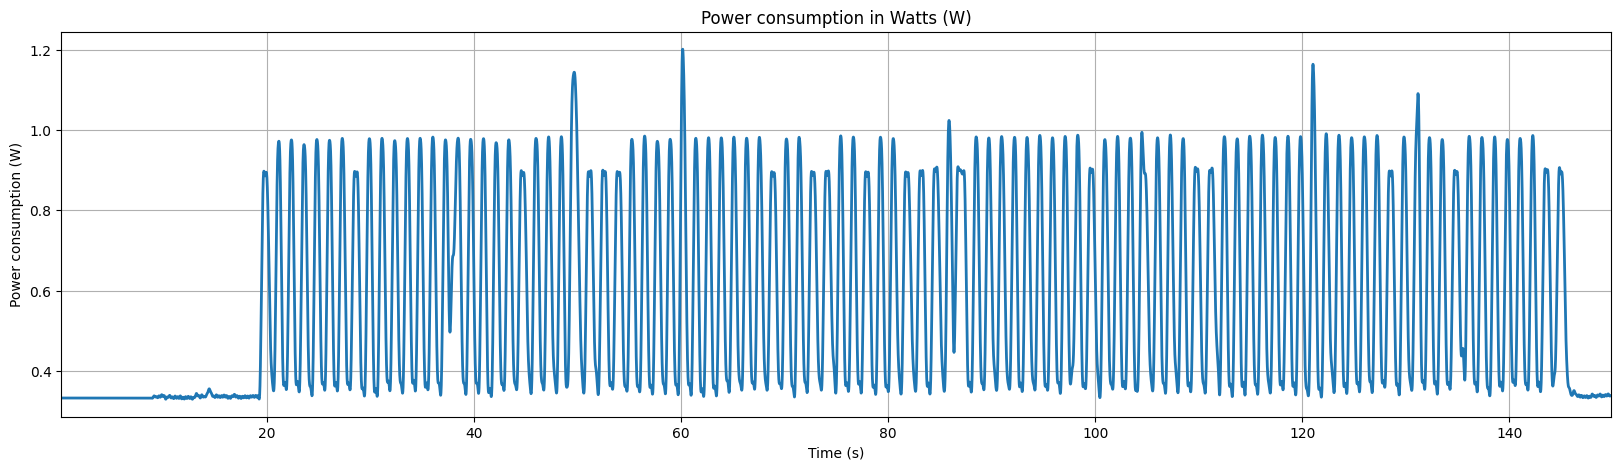

In [40]:
# Apply median filtering
df["median_filtered"]=median_filter_data(df['EVM1 POWER Results (W)'],kernel_size)

# Apply low-pass filtering
df["lowpass_filtered"] = lowpass_filter(df['median_filtered'], cutoff, fs)

# Smooth the data using a rolling average
df["smoothed"] = average_data(df['lowpass_filtered'], window_size)

# Compute threshold
threshold = get_threshold(df['smoothed'].dropna().values)
print("Threshold value:", threshold)

#average_power_active,variance_active,average_power_idle,variance_idle= compute_means_variances(df['smoothed'], threshold)
results = compute_means_variances(df, threshold, sampling_interval, inferences_per_cycle)

print(f"Variance (active state, > threshold): {results['power_var_W2']:.5f} W²")
print(f"Average power (active state, > threshold): {results['power_avg_W']:.5f} W")
# print(f"Variance (idle state, < threshold): {results['avg_power_idle_variance_W2']:.5f} W²")
# print(f"Average power (idle state, < threshold): {results['avg_power_idle_W']:.5f} W")
print(f"Energy (J): {results['energy_avg_J']:.5f} J")
print(f"Energy variance (J²): {results['energy_var_J2']:.5f} J²")

#print("Final Results: average:", results['power_offset_W'])
#print("Final Results: variance:", variance_active -  variance_idle)

# Show the data
show_data(df, sampling_interval)
